In [35]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

## PCA on S&P Industrial Returns

In [103]:
def PCA_with_Omitted_Stock(df, omitted_ticker, PCA_components=2):
    """
    Perform PCA on the stock data after omitting a specific stock ticker.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing stock data with tickers as columns.
    omitted_ticker (str): The ticker to omit from the PCA analysis.
    PCA_components (int): Number of PCA components to retain.
    
    Returns:
    pd.DataFrame: DataFrame containing the PCA results.
    """
    
    # Omit the specified ticker
    df_omitted = df.drop(columns=[omitted_ticker])
    
    # Impute missing values
    imputer = SimpleImputer(strategy='mean')
    df_imputed = pd.DataFrame(imputer.fit_transform(df_omitted), columns=df_omitted.columns)
    
    # Standardize the data
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)
    
    # Perform PCA
    pca = PCA(n_components=PCA_components)
    pca_result = pca.fit_transform(df_scaled)

    pca_df = pd.DataFrame({'PCA Explained Variance' : pca.explained_variance_, 
    'PCA Explained Variance Ratio' : pca.explained_variance_ratio_}, index=[f'PC{i+1}' for i in range(PCA_components)])
    
    pca_df['Cumulative Explained Variance Ratio'] = pca_df['PCA Explained Variance Ratio'].cumsum() * 100
    pca_df['Cumulative Explained Variance'] = pca_df['PCA Explained Variance'].cumsum()
    
    return pca_df.iloc[- 1, 2], pca_df.iloc[-1, 3]

In [109]:
def PCA_Omitted_Loop(df, PCA_components=42):
    """
    Loop through all tickers in the DataFrame and perform PCA after omitting each ticker.
    
    Parameters:
    PCA_components (int): Number of PCA components to retain.
    
    Returns:
    pd.DataFrame: DataFrame containing PCA results for each omitted ticker.
    """
    
    variance_ratios = {}
    variances = {}
    for ticker in df.columns:
        ratio, variance = PCA_with_Omitted_Stock(df=industrial_df, omitted_ticker=ticker, PCA_components=PCA_components)
        variance_ratios[ticker] = ratio
        variances[ticker] = variance


    return variance_ratios, variances

<Axes: title={'center': 'Marginal Variance Ratio Contribution by Omitted Ticker'}>

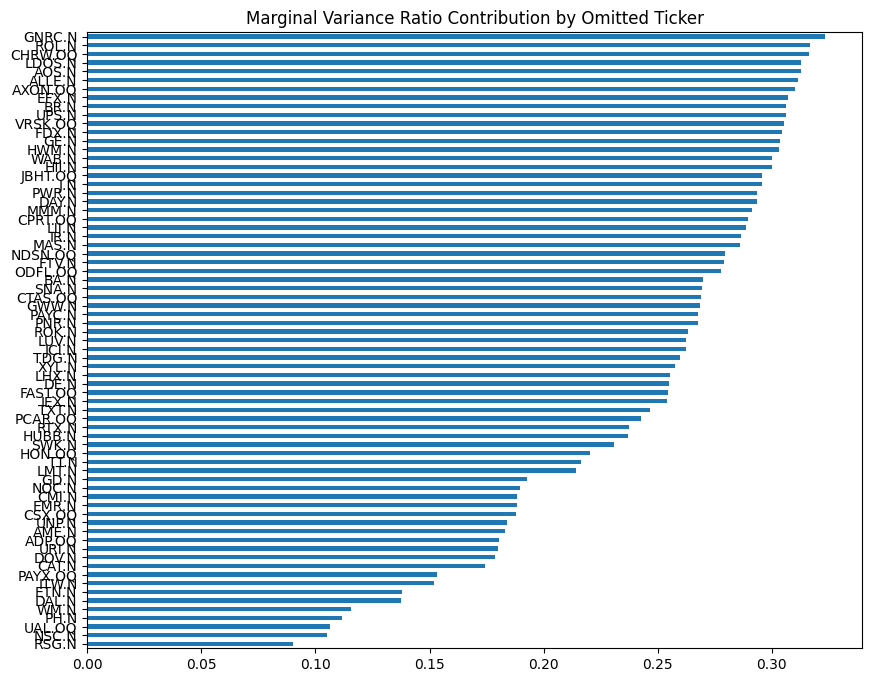

In [159]:
variance_ratios, variances = PCA_Omitted_Loop(industrial_df, 42)
results = pd.DataFrame({'Explained Variance Ratios' : variance_ratios.values(),
                        'Explained Variances' : variances.values()},
                        index=[i for i in variance_ratios.keys()])
results['Marginal Variance Ratio'] = results['Explained Variance Ratios'] - PCA_Statistics.loc['PC42', 'Cumulative Explained Variance Ratio']
results['Marginal Variance'] = results['Explained Variances'] - PCA_Statistics.loc['PC42', 'Cumulative Explained Variance']
results.sort_values(by = 'Marginal Variance Ratio')['Marginal Variance Ratio'].plot(kind='barh', figsize=(10, 8), title='Marginal Variance Ratio Contribution by Omitted Ticker')

In [43]:
'''
Use adfuller(x, maxlag=None, regression='c', autolag
='AIC', store=False, regresults=False)

Returns the following:
    - adf (float) – Test statistic
    - pvalue (float) – p-value    
'''
def ADF_test(time_series):

    test_results = adfuller(time_series.dropna())
    test_statistic = test_results[0]
    p_value = test_results[1]

    #Critical Values
    Critical_Values = {}
    for threshold, adf_stat in test_results[4].items():
        Critical_Values[threshold] = adf_stat

    return test_statistic, p_value, Critical_Values['1%'], Critical_Values['5%'], Critical_Values['10%']


# Testing Monthly Data
Results = industrial_df.apply(lambda col : ADF_test(col)).round(2).T
Results.columns = ['T-stat', 'p-value', '1%', '5%', '10%']
(Results['p-value'] > 0.05).any()

,T-stat,p-value,1%,5%,10%
CHRW.OQ,-13.22,0.0,-3.43,-2.86,-2.57
WM.N,-12.38,0.0,-3.43,-2.86,-2.57
BA.N,-12.58,0.0,-3.43,-2.86,-2.57
PAYX.OQ,-12.60,0.0,-3.43,-2.86,-2.57
MAS.N,-11.49,0.0,-3.43,-2.86,-2.57
...,...,...,...,...,...
ETN.N,-13.06,0.0,-3.43,-2.86,-2.57
XYL.N,-11.57,0.0,-3.43,-2.86,-2.57
LII.N,-17.62,0.0,-3.43,-2.86,-2.57
LMT.N,-13.94,0.0,-3.43,-2.86,-2.57


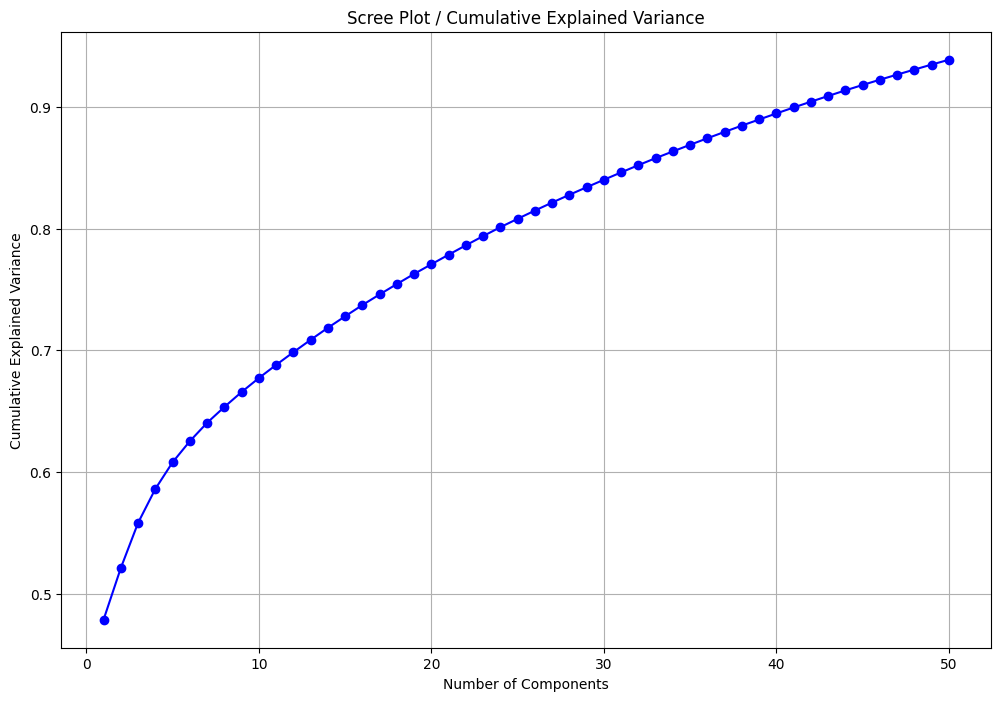

In [46]:
n_components = 50
scaler = StandardScaler()

#Read in data and scale it
industrial_df = pd.read_csv('SP_Industrial_index_constituent_returns_v3.csv', index_col = [0], parse_dates = True)
X_scaled = scaler.fit_transform(industrial_df)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [82]:
PCA_Statistics = pd.DataFrame({'Explained Variance' : PCA_.explained_variance_, 'Explained Variance Ratio (%)' : PCA_.explained_variance_ratio_}, 
                            index=X_PCA.columns)
PCA_Statistics['Cumulative Explained Variance Ratio'] = PCA_Statistics['Explained Variance Ratio (%)'].cumsum() * 100
PCA_Statistics['Cumulative Explained Variance'] = PCA_Statistics['Explained Variance'].cumsum()
PCA_Statistics

,Explained Variance,Explained Variance Ratio (%),Cumulative Explained Variance Ratio,Cumulative Explained Variance
PC1,34.018075,0.478828,47.882780,34.018075
PC2,3.013879,0.042422,52.125022,37.031954
PC3,2.633676,0.037071,55.832102,39.665630
PC4,1.979190,0.027858,58.617948,41.644820
PC5,1.554897,0.021886,60.806573,43.199717
PC6,1.231649,0.017336,62.540203,44.431366
PC7,1.071393,0.015081,64.048262,45.502759
PC8,0.923852,0.013004,65.348647,46.426611
PC9,0.872051,0.012275,66.576119,47.298661
PC10,0.814932,0.011471,67.723192,48.113594


We need 7 principal components to explain 95% of the variance within the S&P industrials index. We can now use the PCA-based subsetting methodology to identify a small number of stocks that can best replicate this

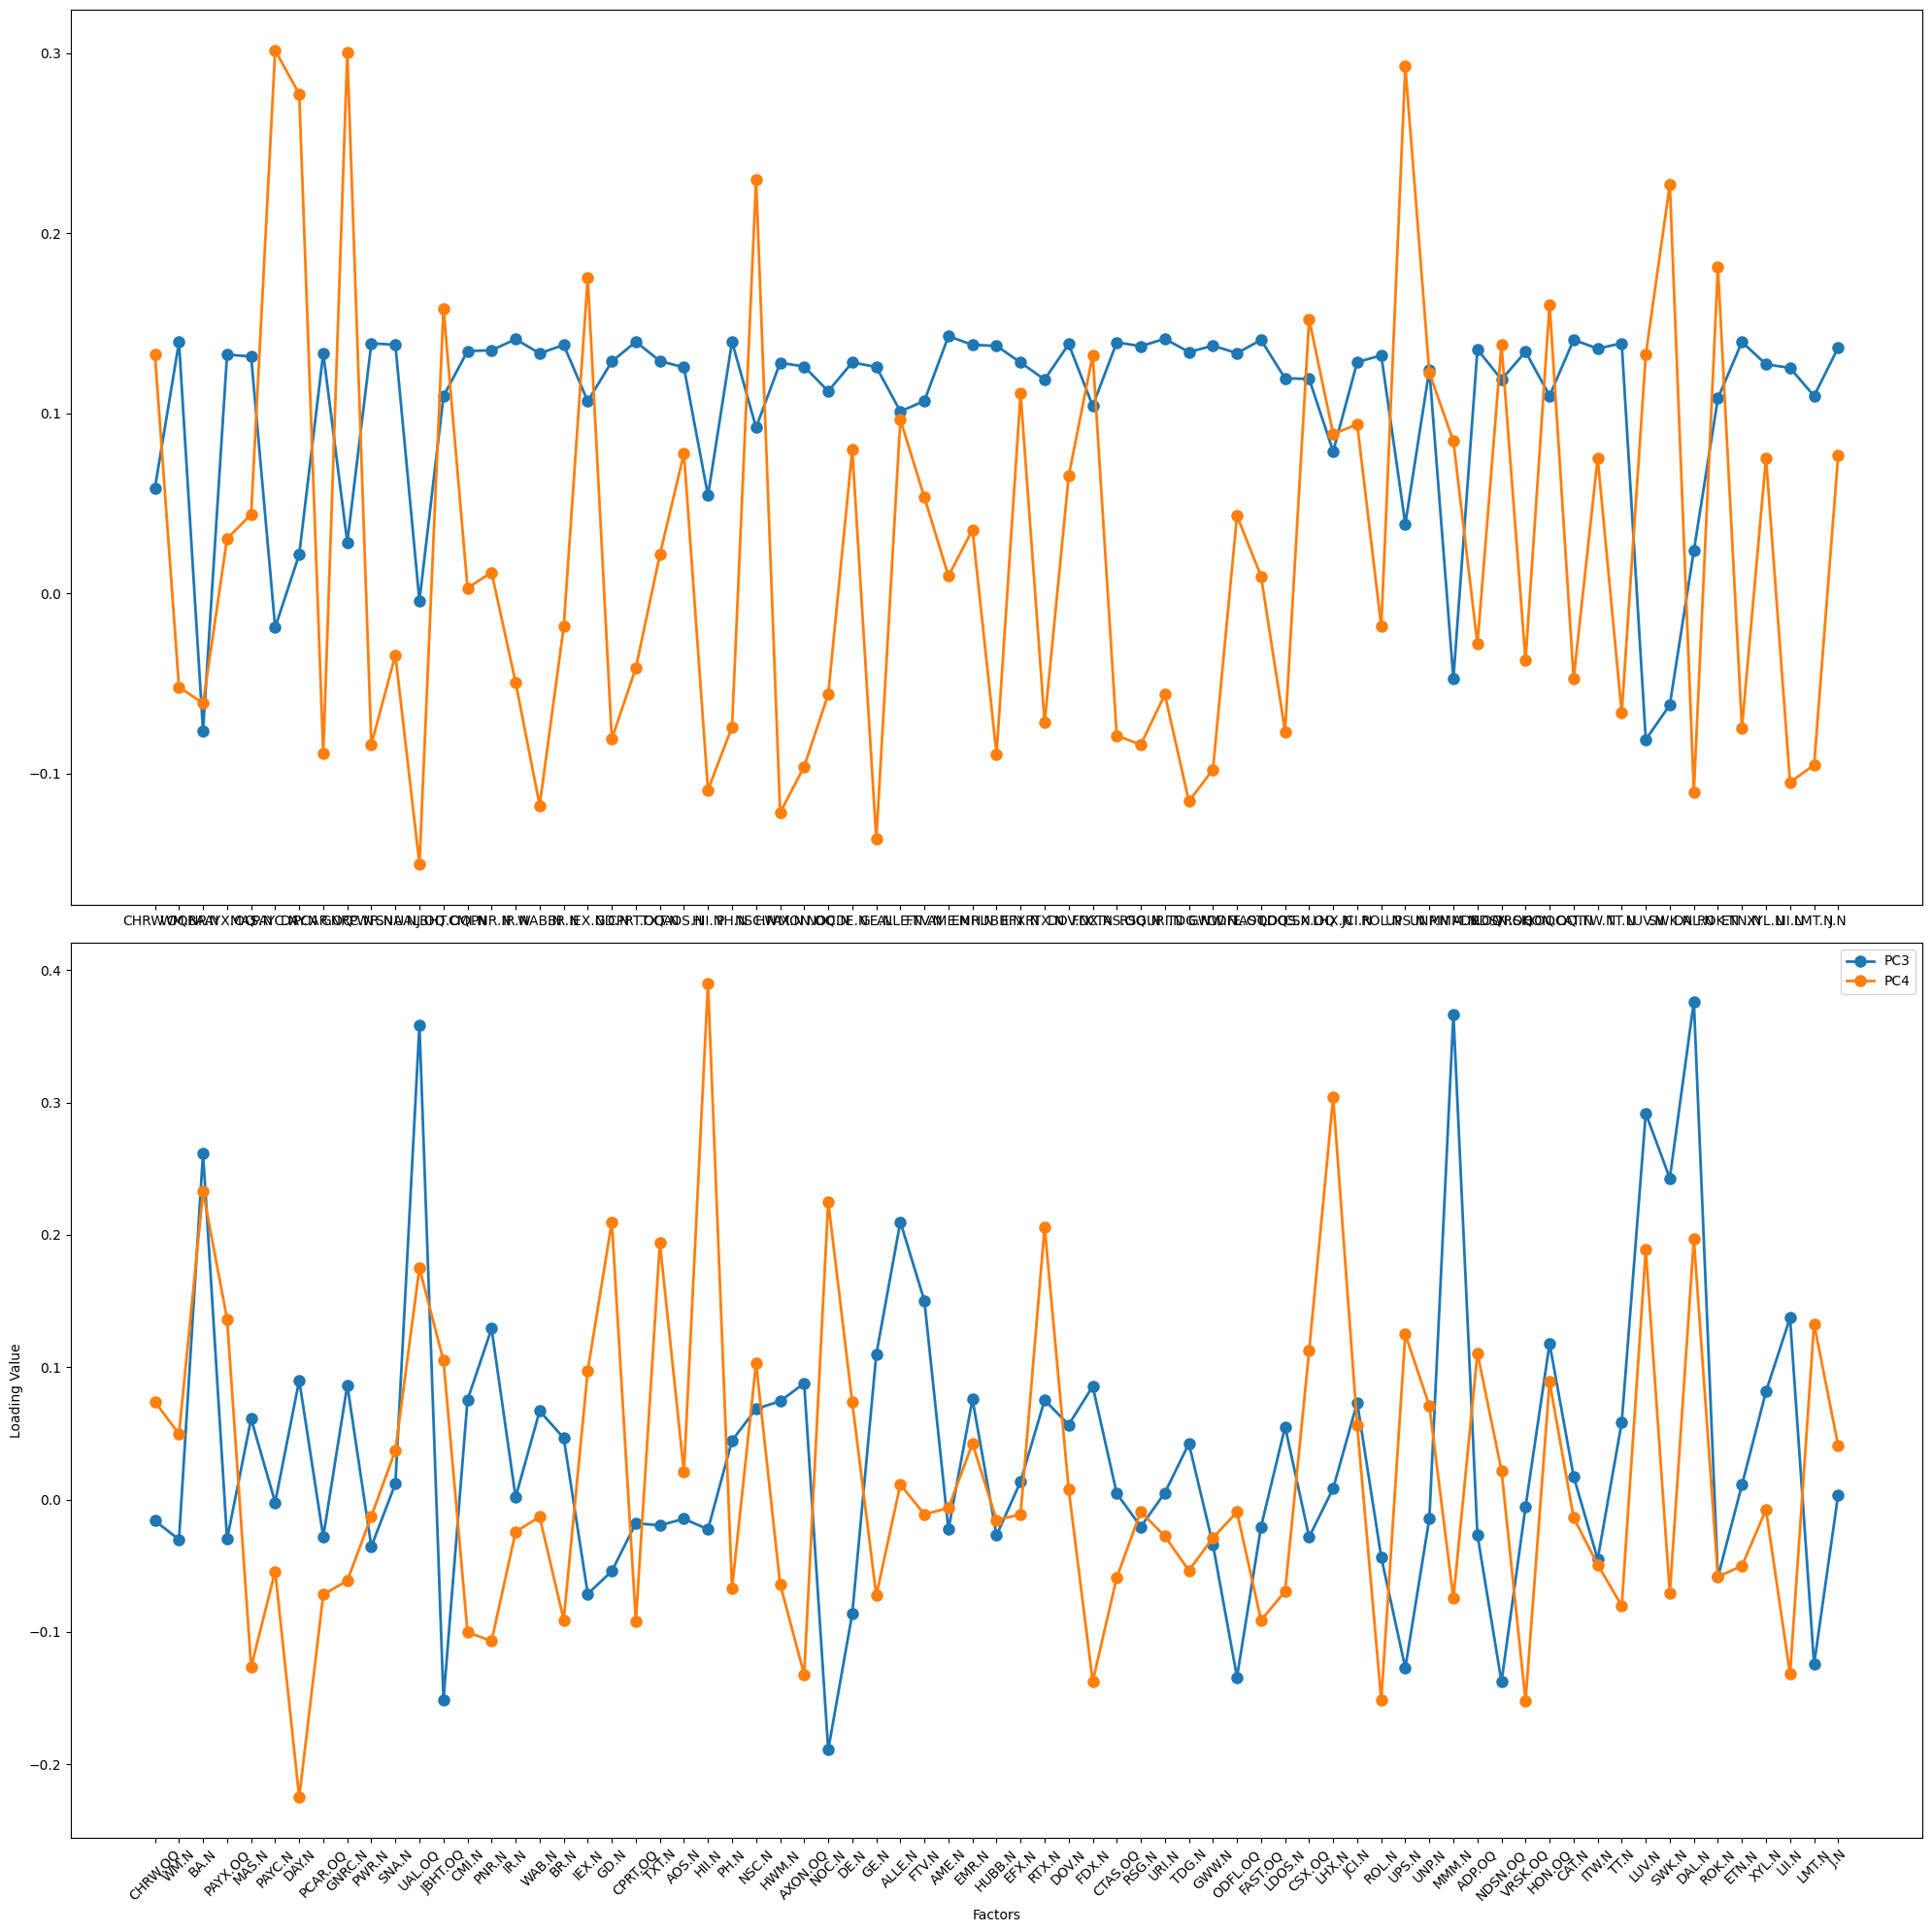

In [ ]:
#Change number of PCs to plot

# Get component loadings
loadings = pd.DataFrame(
    PCA_.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=industrial_df.columns
)

# Plot loadings for first n PCs on a single plot

PC_per_plot = 2 #Number of PCs to plot up to
Number_of_plots = 2
fig, axs = plt.subplots(Number_of_plots, 1, figsize=(20, 20))
axs = axs.flatten()
count = 0

for i in range(Number_of_plots):
    
    for j in range(PC_per_plot):
        axs[i].plot(loadings.index, loadings[f'PC{count+1}'], 
                marker='o', 
                linewidth=2, 
                markersize=8,
                label=f'PC{count+1}',
               )

        count = count + 1

    else:
        pass

plt.xlabel('Factors')
plt.ylabel('Loading Value')
plt.grid(False)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [47]:
Contributor_Score = {}


# Print top contributors for each PC
print("Top contributors to each principal component:")


for i in range( n_components):
    print(f"\nPC{i+1} (variance explained : {PCA_.explained_variance_ratio_[i].round(2)}):")
    top_contributors = loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(5)
    for stock, loading in top_contributors.items():
        print(f"{stock}: {loading:.3f}")
        if stock not in Contributor_Score.keys():
            Contributor_Score[stock] = loading * PCA_.explained_variance_ratio_[i]
        else:
            Contributor_Score[stock] = Contributor_Score[stock] + loading * PCA_.explained_variance_ratio_[i]
            


Top contributors to each principal component:

PC1 (variance explained : 0.67):
AME.N: 0.143
URI.N: 0.141
IR.N: 0.141
CAT.N: 0.141
FAST.OQ: 0.141

PC2 (variance explained : 0.12):
PAYC.N: 0.302
GNRC.N: 0.300
UPS.N: 0.293
DAY.N: 0.277
NSC.N: 0.230

PC3 (variance explained : 0.07):
DAL.N: 0.376
MMM.N: 0.367
UAL.OQ: 0.358
LUV.N: 0.292
BA.N: 0.262

PC4 (variance explained : 0.03):
HII.N: 0.390
LHX.N: 0.304
BA.N: 0.233
NOC.N: 0.225
DAY.N: 0.225

PC5 (variance explained : 0.03):
CHRW.OQ: 0.364
FTV.N: 0.315
LHX.N: 0.300
HII.N: 0.267
BA.N: 0.261

PC6 (variance explained : 0.02):
CHRW.OQ: 0.371
LHX.N: 0.351
HII.N: 0.332
LDOS.N: 0.306
ALLE.N: 0.304

PC7 (variance explained : 0.01):
PAYC.N: 0.365
CHRW.OQ: 0.337
FDX.N: 0.335
DAY.N: 0.315
UNP.N: 0.251

PC8 (variance explained : 0.01):
LMT.N: 0.447
CHRW.OQ: 0.247
CMI.N: 0.241
IEX.N: 0.231
LDOS.N: 0.229

PC9 (variance explained : 0.01):
XYL.N: 0.421
ROL.N: 0.320
DAL.N: 0.270
HON.OQ: 0.269
UAL.OQ: 0.245

PC10 (variance explained : 0.01):
CHRW.OQ: 0.34